# Baseline Models

## Objective

The objective of this notebook is to establish reliable baseline performance for the Telco Churn classification problem.

This notebook will:

- train a `DummyClassifier` to establish a minimum reference performance;
- train Logistic Regression as a simple, interpretable linear baseline;
- train a Decision Tree as a nonlinear baseline;
- generate class predictions and churn probabilities;
- create a reusable evaluation function;
- evaluate each model using accuracy, precision, recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC;
- analyze confusion matrices, with particular attention to false negatives;
- compare training and validation performance to identify possible overfitting;
- summarize the initial strengths and limitations of each baseline model.

Because the target is imbalanced, accuracy will not be used as the only evaluation criterion. Particular attention will be given to recall and F1-score for the churn class because failing to identify customers who are likely to leave may represent an important business cost.

Model comparison will be performed using only the training data and cross-validation. The test set will remain untouched until the final model and decision threshold have been selected.

In [1]:
import pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
import numpy as np
import math
from IPython.display import display
import joblib
import matplotlib.pyplot as plt

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## Load modeling data and fitted preprocessor

The audited dataset is loaded and divided using the same configuration established in the preprocessing notebook. Because the split uses a fixed `random_state` and stratification, it reproduces the same training and test observations.

The previously fitted preprocessor is then loaded and used to transform both datasets. It is not refitted in this notebook, ensuring that the transformations learned exclusively from the training data remain unchanged.

The feature metadata is also loaded to assign meaningful column names to the transformed matrices.

In [2]:
SPLIT_DATA_DIR = Path("../data/processed/splits")

train_data = pd.read_csv(SPLIT_DATA_DIR / "train.csv")
test_data = pd.read_csv(SPLIT_DATA_DIR / "test.csv")

X_train = train_data.drop(columns="Churn")
y_train = train_data["Churn"]

X_test = test_data.drop(columns="Churn")
y_test = test_data["Churn"]

In [3]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_PATH = DATA_DIR / "processed" / "column_audit.csv"
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {PROCESSED_DATA_PATH.resolve()}")
column_audit = pd.read_csv(PROCESSED_DATA_PATH, index_col=0)
column_audit

,column,dtype,unique_count,possible_role
0,customerID,str,7043,identifier
1,gender,str,2,binary categorical
2,SeniorCitizen,int64,2,binary categorical stored as integer
3,Partner,str,2,binary categorical
4,Dependents,str,2,binary categorical
5,tenure,int64,73,numeric
6,PhoneService,str,2,binary categorical
7,MultipleLines,str,3,multiclass categorical
8,InternetService,str,3,multiclass categorical
9,OnlineSecurity,str,3,multiclass categorical


In [4]:
expected_features = column_audit.loc[~column_audit["column"].isin(["customerID", "Churn"]),"column"].copy()
n_expected_features = len(expected_features)

print(expected_features)
print("Number of expected features:", n_expected_features)

1               gender
2        SeniorCitizen
3              Partner
4           Dependents
5               tenure
6         PhoneService
7        MultipleLines
8      InternetService
9       OnlineSecurity
10        OnlineBackup
11    DeviceProtection
12         TechSupport
13         StreamingTV
14     StreamingMovies
15            Contract
16    PaperlessBilling
17       PaymentMethod
18      MonthlyCharges
19        TotalCharges
Name: column, dtype: str
Number of expected features: 19


In [5]:
MODELS_DIR = Path("../models")
PREPROCESSOR_PATH = MODELS_DIR / "preprocessor.joblib"
if not PREPROCESSOR_PATH.exists():
    raise FileNotFoundError(f"preprocessor not found at {PREPROCESSOR_PATH.resolve()}")
preprocessor = joblib.load(PREPROCESSOR_PATH)

In [6]:
assert "customerID" not in expected_features, "customerID should have been excluded"
assert "Churn" not in expected_features, "Churn should have been excluded"
assert len(expected_features) == len(column_audit["column"]) - 2, "Should be total columns minus customerID and Churn"

In [7]:
assert set(X_train.columns) == set(expected_features), (
    f"Mismatch in X_train columns.\n"
    f"Missing: {set(expected_features) - set(X_train.columns)}\n"
    f"Extra: {set(X_train.columns) - set(expected_features)}"
)

assert set(X_test.columns) == set(expected_features), (
    f"Mismatch in X_test columns.\n"
    f"Missing: {set(expected_features) - set(X_test.columns)}\n"
    f"Extra: {set(X_test.columns) - set(expected_features)}"
)

### Feature schema validation results

The expected predictor schema was validated successfully before model training.

The `customerID` identifier and `Churn` target are excluded from the predictor set, leaving 19 expected input features. Both `X_train` and `X_test` contain exactly these features, with no missing or unexpected columns.

This confirms that the modeling data is structurally consistent with the schema used to build the fitted preprocessor. The validated feature set can now be transformed safely using the previously saved preprocessing artifact.

## Baseline model pipelines

A consistent machine-learning pipeline will be created for each baseline classifier. Each pipeline combines the preprocessing stage with a model, allowing the classifiers to receive the same feature transformations and ensuring a fair comparison.

The baseline models included are:

- `DummyClassifier`, which establishes the minimum reference performance;
- `LogisticRegression`, which provides a simple linear baseline;
- `DecisionTreeClassifier`, which captures nonlinear relationships;
- `RandomForestClassifier`, which combines multiple decision trees to improve stability and generalization.

The preprocessing and model steps are kept together to reduce the risk of applying inconsistent transformations. During cross-validation, the preprocessing stage must be fitted separately within each training fold to prevent information from the validation folds from influencing the transformations.

In [8]:
display(type(X_train), X_train.shape)
display(type(y_train), y_train.shape)
display(type(preprocessor))

pandas.DataFrame

(5634, 19)

pandas.Series

(5634,)

sklearn.compose._column_transformer.ColumnTransformer

In [9]:
model = {
    "dummy": DummyClassifier(),
    "logistic_regression": LogisticRegression(),
    "decision_tree": DecisionTreeClassifier(),
    "random_forest": RandomForestClassifier()
}

In [10]:
baseline_pipeline = {
    model_name: Pipeline([
        ('preprocessing', preprocessor),
        ('model', estimator)
    ])
    for model_name, estimator in model.items()
}

### Baseline model pipelines

A separate machine-learning pipeline was created for each baseline model. Every pipeline contains two stages:

1. The fitted preprocessing configuration transforms the original customer features.
2. A classifier receives the transformed features and produces churn predictions.

Four baseline models were included for comparison:

- **Dummy Classifier**: predicts the majority class regardless of input; establishes the minimum performance any real model must exceed.
- **Logistic Regression**: a simple, interpretable linear model, commonly used as a first real baseline for binary classification.
- **Decision Tree**: captures non-linear relationships and feature interactions without requiring scaled inputs.
- **Random Forest**: an ensemble of decision trees, typically more robust and less prone to overfitting than a single tree.

### Pipeline construction validation

Each pipeline was validated to confirm it was built correctly before training:

- Every model defined in `model` has a corresponding pipeline in `baseline_pipeline`, with matching keys.
- Each pipeline contains exactly two named steps: `preprocessing` and `model`.
- The `model` step in each pipeline references the exact same estimator instance defined in the original `model` dictionary.

These checks confirm that no pipeline was built with the wrong estimator or missing the preprocessing stage before proceeding to training.

In [11]:
assert set(baseline_pipeline.keys()) == set(model.keys())

for model_name, pipeline in baseline_pipeline.items():
    assert "preprocessing" in pipeline.named_steps
    assert "model" in pipeline.named_steps

    assert pipeline.named_steps["model"] is model[model_name]

print("All baseline pipelines were created correctly.")

All baseline pipelines were created correctly.


## Fit baseline models

Each baseline pipeline is fitted using only the untransformed training data. During fitting, the pipeline first learns the preprocessing parameters from `X_train` and then trains its classifier using the transformed features.

The test set is not used during this stage because it must remain untouched for the final evaluation. Fitting all baseline models through the same pipeline structure ensures consistent preprocessing and a fair comparison.

In [12]:
fitted_baseline_pipelines = {}

for model_name, pipeline in baseline_pipeline.items():
    pipeline.fit(X_train, y_train)
    fitted_baseline_pipelines[model_name] = pipeline

    print(f"{model_name} fitted successfully.")

dummy fitted successfully.
logistic_regression fitted successfully.
decision_tree fitted successfully.
random_forest fitted successfully.


### Fitting verification

All baseline pipelines were fitted successfully using only the training data. Each pipeline learned its preprocessing parameters and classifier parameters without accessing the test set.

No conclusions about model performance are drawn at this stage. The baseline models will be compared in the following section using stratified cross-validation, class-specific metrics, and out-of-fold confusion matrices. The test set remains untouched and reserved for the final evaluation of the selected model.

## Generate baseline predictions

The fitted baseline pipelines are used to generate predictions for the test observations. Each pipeline applies its learned preprocessing transformations before using its classifier to predict whether each customer belongs to the non-churn class (`0`) or churn class (`1`).

The predictions are stored by model and will be analyzed in the following section using classification reports, confusion matrices, and a metric comparison table.

In [13]:
predictions = {}

for model_name, pipeline in fitted_baseline_pipelines.items():
    y_pred = pipeline.predict(X_test)
    predictions[model_name] = y_pred

    assert len(y_pred) == len(y_test)
    assert set(y_pred).issubset({0, 1})

    print(f"{model_name}: predictions generated successfully.")

dummy: predictions generated successfully.
logistic_regression: predictions generated successfully.
decision_tree: predictions generated successfully.
random_forest: predictions generated successfully.


### Prediction verification

Every fitted baseline model generated one prediction for each observation in the test set. The predicted values contain only the valid classes `0` and `1`.

No performance conclusions are drawn from the predictions alone. In the following section, the predictions will be compared with the actual target values using classification metrics and confusion matrices.

## Confusion matrices and metric comparison

The baseline models are evaluated by comparing their predictions for `X_test` with the actual target values in `y_test`. Classification reports, confusion matrices, and a metric comparison table are used to examine how effectively each model distinguishes between non-churn customers (`0`) and churn customers (`1`).

The evaluation includes accuracy, balanced accuracy, ROC-AUC, PR-AUC, and class-specific precision, recall, and F1-score. Although both classes are evaluated, particular attention is given to class `1`, which represents customer churn.

The confusion matrices show the number of:

- **True Negatives (TN):** non-churn customers correctly classified as non-churn.
- **False Positives (FP):** non-churn customers incorrectly classified as churn.
- **False Negatives (FN):** churn customers incorrectly classified as non-churn.
- **True Positives (TP):** churn customers correctly classified as churn.

False negatives are especially important because they represent customers who churn but are not detected by the model. However, reducing false negatives may increase false positives, so churn recall must be considered together with precision and F1-score.

The purpose of this comparison is to understand the behavior of the untuned baseline models and identify which models should be considered for further optimization. No baseline model will be selected using accuracy alone because the target classes are imbalanced.

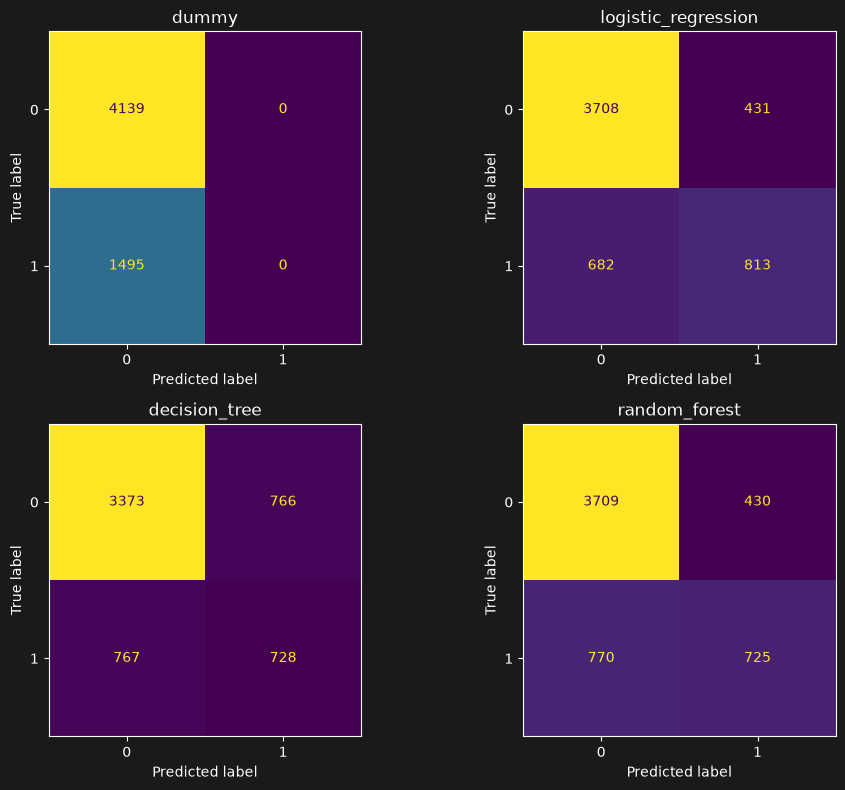

In [14]:
n_models = len(baseline_pipeline)
n_columns = 2
n_rows = math.ceil(n_models / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(5 * n_columns, 4 * n_rows))
axes = axes.flatten()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ax, (model_name, pipeline) in zip(axes, baseline_pipeline.items()):

    y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv, method="predict")
    cm = confusion_matrix(y_train, y_pred_cv)
    classes = sorted(y_train.unique())

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

for extra_ax in axes[n_models:]:
    extra_ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
for model_name, y_pred in predictions.items():
    print(f"--- {model_name} ---")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )
    print()

--- dummy ---
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409


--- logistic_regression ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


--- decision_tree ---
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.50      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted

In [16]:
existing_classes = sorted(y_train.unique())

base_metrics = {
    "precision": precision_score,
    "recall": recall_score,
    "f1": f1_score,
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

for metric_name, metric_function in base_metrics.items():
    for classes in existing_classes:
        scoring[f"{metric_name}_class_##{classes}##"] = make_scorer(metric_function, pos_label=classes)

cv_results = {}

for model_name, pipeline in baseline_pipeline.items():
    cv_results[model_name] = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    print(f"{model_name} evaluated successfully.")

/Users/emiliogarcialopez/projectGitHub/telco-churn-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/emiliogarcialopez/projectGitHub/telco-churn-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/emiliogarcialopez/projectGitHub/telco-churn-project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to

dummy evaluated successfully.
logistic_regression evaluated successfully.
decision_tree evaluated successfully.
random_forest evaluated successfully.


In [17]:
summary = []

for model_name, results in cv_results.items():
    row = {"model": model_name}

    for key, values in results.items():
        if key.startswith("test_") or key.startswith("train_"):
            row[f"{key}_mean"] = values.mean()*100
            row[f"{key}_std"] = values.std()

    summary.append(row)

cv_summary = pd.DataFrame(summary).T
display(cv_summary.round(3))

,0,1,2,3
model,dummy,logistic_regression,decision_tree,random_forest
test_accuracy_mean,73.464675,80.245106,72.949877,78.452469
test_accuracy_std,0.000094,0.011979,0.010774,0.010463
train_accuracy_mean,73.464679,80.631005,99.831382,99.826945
train_accuracy_std,0.000024,0.003327,0.000226,0.000259
test_balanced_accuracy_mean,50.0,71.984285,65.502137,68.456859
test_balanced_accuracy_std,0.0,0.019918,0.011512,0.012668
train_balanced_accuracy_mean,50.0,72.535239,99.698297,99.738007
train_balanced_accuracy_std,0.0,0.005413,0.000436,0.0004
test_roc_auc_mean,50.0,84.615792,65.541093,81.933242


In [18]:
y_true = y_test

expected_models = set(baseline_pipeline.keys())

assert set(predictions.keys()) == expected_models, (
    "The models stored in predictions do not match "
    "the models in baseline_pipeline."
)

expected_classes = set(y_true.unique())
class_labels = sorted(expected_classes)
n_classes = len(class_labels)

for model_name, y_pred in predictions.items():
    predicted_classes = set(np.unique(y_pred))

    assert len(y_pred) == len(y_true), (
        f"{model_name}: expected {len(y_true)} predictions, "
        f"but received {len(y_pred)}."
    )

    assert predicted_classes.issubset(expected_classes), (
        f"{model_name} predicted unexpected classes: "
        f"{predicted_classes - expected_classes}"
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_labels
    )

    assert cm.shape == (n_classes, n_classes), (
        f"{model_name}: unexpected confusion-matrix shape "
        f"{cm.shape}."
    )

    assert cm.sum() == len(y_true), (
        f"{model_name}: the confusion matrix contains "
        f"{cm.sum()} observations instead of {len(y_true)}."
    )

    print(
        f"{model_name}: validated "
        f"(confusion matrix shape: {cm.shape})"
    )

    if n_classes == 2:
        tn, fp, fn, tp = cm.ravel()
        print(f"    TN={tn}, FP={fp}, FN={fn}, TP={tp}")

print("\nAll test predictions and confusion matrices are valid.")

dummy: validated (confusion matrix shape: (2, 2))
    TN=1035, FP=0, FN=374, TP=0
logistic_regression: validated (confusion matrix shape: (2, 2))
    TN=926, FP=109, FN=165, TP=209
decision_tree: validated (confusion matrix shape: (2, 2))
    TN=837, FP=198, FN=186, TP=188
random_forest: validated (confusion matrix shape: (2, 2))
    TN=921, FP=114, FN=190, TP=184

All test predictions and confusion matrices are valid.


### Prediction validation

All baseline models generated exactly one prediction for each observation in the test set. The predictions contained only the expected target classes, and each confusion matrix accounted for all test observations.

These checks confirm that the stored predictions are structurally valid and correctly aligned with `y_test`. Model performance can therefore be interpreted using the classification reports, confusion matrices, and metric comparison.

### Baseline model results

The baseline comparison confirms that accuracy alone is not sufficient for this imbalanced classification problem. The `DummyClassifier` achieved approximately 73% accuracy by predicting every customer as non-churn. However, it failed to detect any churn customers, producing zero recall and zero F1-score for class `1`.

`LogisticRegression` provided the strongest overall baseline performance. It achieved approximately 80% cross-validation accuracy, 72% balanced accuracy, 0.85 ROC-AUC, and 0.66 PR-AUC. It detected approximately 54% of churn customers while maintaining a churn precision of approximately 65%. Among the evaluated baselines, it produced the highest churn F1-score and the fewest false negatives.

The unrestricted `DecisionTreeClassifier` detected approximately 50% of churn customers, but its churn precision and overall validation performance were lower than those of Logistic Regression. Its training metrics were close to 100%, while its validation accuracy was approximately 73%. This large difference provides strong evidence of overfitting.

The `RandomForestClassifier` generalized better than the individual Decision Tree and achieved approximately 79% validation accuracy. Nevertheless, its churn recall was approximately 48%, meaning that it missed more churn customers than Logistic Regression. Its nearly perfect training metrics also indicate overfitting under the current default configuration.

Overall, Logistic Regression is the most promising baseline because it provides the best balance between churn precision, churn recall, F1-score, balanced accuracy, ROC-AUC, and PR-AUC. Decision Tree and Random Forest require regularization and hyperparameter tuning before they can be compared fairly with the linear model.

These results represent baseline performance rather than final model performance. Model tuning, threshold optimization, and business-cost analysis will be conducted before selecting the final model.

## Initial modeling conclusions

This notebook established and evaluated the first baseline models for predicting customer churn. The comparison showed that accuracy alone is not sufficient because the target is imbalanced. This was demonstrated by the `DummyClassifier`, which achieved approximately 73% accuracy while failing to identify any churn customers.

Among the evaluated models, `LogisticRegression` produced the strongest and most balanced baseline results. It achieved approximately 81% test accuracy, 56% recall, 66% precision, and a 60% F1-score for the churn class. It also performed more consistently than the tree-based baselines.

The unrestricted `DecisionTreeClassifier` showed signs of overfitting and produced weaker test performance. `RandomForestClassifier` generalized better than the individual decision tree, but it detected fewer churn customers than Logistic Regression under its current configuration.

Based on this initial comparison, Logistic Regression is the leading baseline and should be used as the primary reference model in the next modeling stage. However, these results do not represent the final production model. Hyperparameter tuning, decision-threshold optimization, business-cost evaluation, and comparison with additional models may still improve churn detection.

The test predictions and confusion matrices were validated successfully. Each model generated one prediction per test observation, used only the expected target classes, and accounted for all observations in its confusion matrix.

### Initial model decision

`LogisticRegression` is selected as the strongest initial candidate because it currently provides the best balance between detecting churn customers and limiting false churn alerts. The final model selection will also consider the business cost of false negatives and false positives.

### Next steps

The next development stage will:

1. Finalize and persist the selected preprocessing and prediction pipeline.
2. Define the input schema required to represent a customer.
3. create a service layer that loads the trained model and performs predictions.
4. Build a FastAPI application with health-check and prediction endpoints.
5. Validate API inputs and return structured prediction results.
6. Add automated tests, documentation, and error handling.
7. Containerize and deploy the prediction service.

This creates the transition from experimental machine learning code to a reusable prediction service that can be consumed by a frontend, another application, or an external system.